This notebook provides a workflow for building a machine learning model to classify land use types using satellite imagery data. 
The process includes data loading, preprocessing, feature selection, model training with XGBoost, hyperparameter tuning using cross-validation, and evaluation of model performance. The workflow also highlights feature importance and provides steps to save the trained model for future use.

In [1]:
import pandas as pd
import geopandas as gpd

import seaborn as sns


from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import *

from scipy.stats import uniform, randint

In [ ]:
# load the data
data_path = '../data/combined_points_with_data_fin.csv'

data = gpd.read_file(data_path)
data = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.lon, data.lat), crs="EPSG:4326")

for col in data.columns:
    if col not in ['land_use_type', 'geometry', 'lat', 'lon']:
        data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.dropna()

In [4]:
# define the features and the target variable, encode the target variable
X = data[[col for col in data.columns if col not in ['land_use_type', 'geometry', 'lat', 'lon']]]
y = data[['land_use_type']]

le = LabelEncoder()
y_enc = le.fit_transform(y.values.ravel())

In [19]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

In [20]:
# select features with low multicollinearity using VIF
def calculate_vif(training_df, thresh=10.0):
    training_df = training_df.apply(pd.to_numeric, errors='coerce')
    
    training_df = training_df.assign(const=1)  
    variables = list(range(training_df.shape[1]))
    dropped = True
    while dropped:
        dropped = False
        vif = [variance_inflation_factor(training_df.iloc[:, variables].values, ix)
               for ix in range(training_df.iloc[:, variables].shape[1])]
        vif = vif[:-1]  
        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            print('dropping \'' + training_df.iloc[:, variables].columns[maxloc] +
                  '\' at index: ' + str(maxloc) + '\' vif: ' + str(max(vif)))
            del variables[maxloc]
            dropped = True

    print('Remaining variables:')
    print(training_df.columns[variables[:-1]])
    return training_df.iloc[:, variables[:-1]]

numeric_cols = [col for col in X_train.columns if col != 'grid_id']
X_train_numeric = X_train[numeric_cols].apply(pd.to_numeric, errors='coerce')
X_train_ind = X_train_numeric[calculate_vif(X_train_numeric).columns]
X_test_ind = X_test[X_train_ind.columns]


dropping 'B03_1' at index: 4' vif: 155.12405865843718
dropping 'B03_2' at index: 4' vif: 44.988523984792685
dropping 'B02_3' at index: 2' vif: 37.100887091783
dropping 'VV_7' at index: 16' vif: 29.407691052439052
dropping 'VV_8' at index: 16' vif: 24.983282428109202
dropping 'B03_3' at index: 3' vif: 23.537949025431175
dropping 'VH_6' at index: 18' vif: 23.103099248846842
dropping 'VV_5' at index: 13' vif: 21.678525145217666
dropping 'VH_9' at index: 19' vif: 18.612444791662604
dropping 'B04_1' at index: 4' vif: 17.788452857845627
dropping 'VH_8' at index: 17' vif: 16.895543869687383
dropping 'VH_4' at index: 14' vif: 16.26671533487179
dropping 'B03_4' at index: 3' vif: 15.159402661718168
dropping 'B02_2' at index: 1' vif: 14.176136293795325
dropping 'VV_6' at index: 10' vif: 11.568849542160043
Remaining variables:
Index(['B02_1', 'B02_4', 'B04_2', 'B04_3', 'B04_4', 'B08_1', 'B08_2', 'B08_3',
       'B08_4', 'VV_4', 'VV_9', 'VH_5', 'VH_7'],
      dtype='object')


In [21]:
# set up cross-validation
gr = X_train['grid_id']
cv = StratifiedGroupKFold(n_splits=10)
X_train = X_train_ind
X_test = X_test_ind

In [22]:
# define the XGBoost model and hyperparameter search space
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    random_state=42
)


param_distributions = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 6)
}


xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=1000, 
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

xgb_search.fit(X_train, y_train, groups=gr)

print("Best parameters found:", xgb_search.best_params_)
print("Best cross-validated F1 score:", xgb_search.best_score_)

Fitting 10 folds for each of 1000 candidates, totalling 10000 fits
Best parameters found: {'colsample_bytree': np.float64(0.797592594852345), 'gamma': np.float64(0.3773176459300583), 'learning_rate': np.float64(0.040874809223243505), 'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 976, 'subsample': np.float64(0.6509954649327929)}
Best cross-validated F1 score: 0.8419169479999182


In [23]:
# train the model with the best hyperparameters
model_xgb = xgb.XGBClassifier(
    random_state=42,
    objective='multi:softmax',
    **xgb_search.best_params_
)
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

<Axes: >

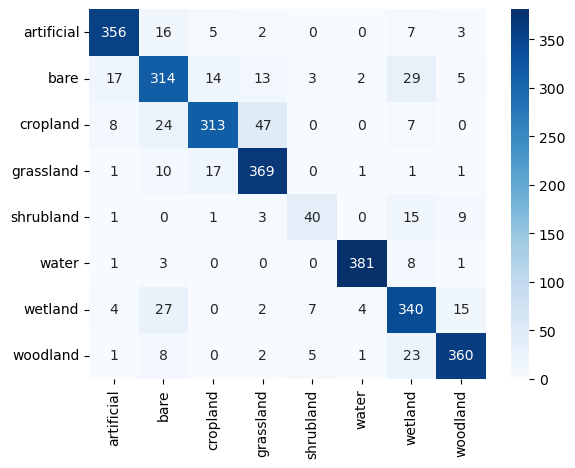

In [24]:
# test set evaluation
# plot a confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

In [25]:
# print classification report
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred),
    target_names=le.classes_
))

              precision    recall  f1-score   support

  artificial       0.92      0.92      0.92       389
        bare       0.78      0.79      0.79       397
    cropland       0.89      0.78      0.84       399
   grassland       0.84      0.92      0.88       400
   shrubland       0.73      0.58      0.65        69
       water       0.98      0.97      0.97       394
     wetland       0.79      0.85      0.82       399
    woodland       0.91      0.90      0.91       400

    accuracy                           0.87      2847
   macro avg       0.86      0.84      0.85      2847
weighted avg       0.87      0.87      0.87      2847



<Axes: xlabel='Importance', ylabel='Feature'>

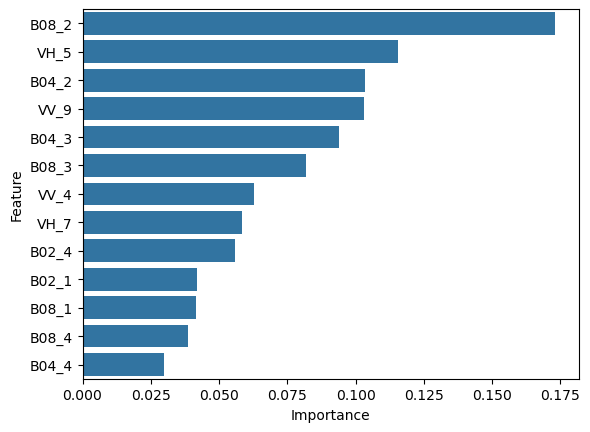

In [26]:
# get most important features
importance = model_xgb.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df)

In [ ]:
# save the model
model_xgb.save_model("./cdse_model_xgb_nosmote.json")